In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_excel('Ecommerce.xlsx')

# Fix date column
df['Date'] = pd.to_datetime(df['Date'], format='%A, %d %B %Y')

# Preview
print("Shape:", df.shape)
print("\nRelevant Columns:")
print(df[['Customer_ID', 'Product_Category', 
          'Total_Amount', 'Is_Returning_Customer']].head(10))

# Check unique categories
print("\nProduct Categories:")
print(df['Product_Category'].unique())

print("\nTotal Unique Customers:", df['Customer_ID'].nunique())

Shape: (17049, 21)

Relevant Columns:
  Customer_ID Product_Category  Total_Amount  Is_Returning_Customer
0  CUST_00056      Electronics   2648.969971                   True
1  CUST_00056           Beauty   1003.750000                   True
2  CUST_00071            Books    231.699997                   True
3  CUST_00310      Electronics   4054.879883                   True
4  CUST_00334           Sports   4190.250000                   True
5  CUST_00369            Books     14.810000                  False
6  CUST_00418    Home & Garden    248.470001                   True
7  CUST_00432            Books    144.199997                   True
8  CUST_00520             Toys    442.529999                   True
9  CUST_00564           Sports    482.910004                   True

Product Categories:
['Electronics' 'Beauty' 'Books' 'Sports' 'Home & Garden' 'Toys' 'Food'
 'Fashion']

Total Unique Customers: 5000


Customer Product Matrix Shape: (5000, 8)

Sample Matrix (first 5 customers):
Product_Category      Beauty  Books  Electronics     Fashion        Food  \
Customer_ID                                                                
CUST_00001          0.000000  29.18          0.0    0.000000    0.000000   
CUST_00002        534.450012   0.00          0.0    0.000000  275.450012   
CUST_00003          0.000000   0.00          0.0    0.000000    0.000000   
CUST_00004          0.000000   0.00          0.0  383.220001    0.000000   
CUST_00005          0.000000   0.00          0.0  529.479980    0.000000   

Product_Category  Home & Garden       Sports        Toys  
Customer_ID                                               
CUST_00001           506.350006  1664.099976    0.000000  
CUST_00002             0.000000     0.000000    0.000000  
CUST_00003          2634.250000     0.000000  396.559998  
CUST_00004             0.000000     0.000000    0.000000  
CUST_00005          1601.010010     

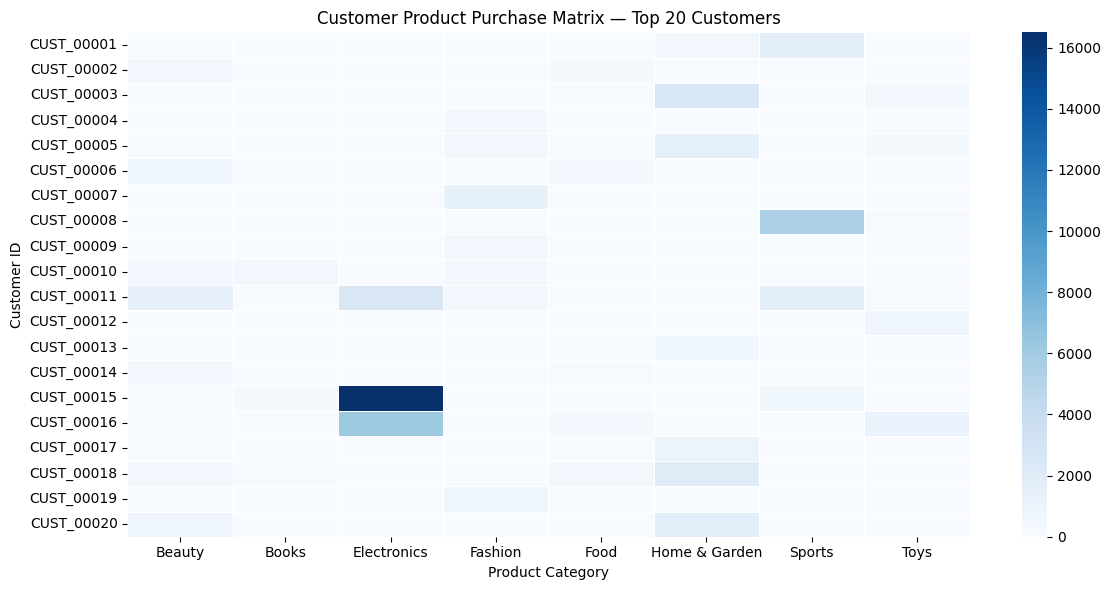

In [3]:
# Build Customer-Product Matrix
customer_product_matrix = df.pivot_table(
    index='Customer_ID',
    columns='Product_Category',
    values='Total_Amount',
    aggfunc='sum',
    fill_value=0
)

print("Customer Product Matrix Shape:", customer_product_matrix.shape)
print("\nSample Matrix (first 5 customers):")
print(customer_product_matrix.head())

# Visualize the matrix
plt.figure(figsize=(12, 6))
sns.heatmap(
    customer_product_matrix.head(20),
    cmap='Blues',
    linewidths=0.5,
    annot=False
)
plt.title('Customer Product Purchase Matrix — Top 20 Customers')
plt.xlabel('Product Category')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()


In [4]:

similarity_matrix = cosine_similarity(customer_product_matrix)

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.index
)

print("Similarity Matrix Shape:", similarity_df.shape)
print("\nSample Similarity Scores (first 5 customers):")
print(similarity_df.iloc[:5, :5])

# Build the recommendation function
def recommend_products(customer_id, n_similar=5, n_recommendations=3):
    
    # Check if customer exists
    if customer_id not in similarity_df.index:
        return f"Customer {customer_id} not found"
    
    # Get top N similar customers (excluding themselves)
    similar_customers = similarity_df[customer_id]\
        .drop(customer_id)\
        .sort_values(ascending=False)\
        .head(n_similar)
    
    print(f"\nTop {n_similar} Similar Customers to {customer_id}:")
    print(similar_customers)
    
    # Get categories already bought
    already_bought = customer_product_matrix.loc[customer_id]
    already_bought = already_bought[already_bought > 0].index.tolist()
    print(f"\nCategories {customer_id} already bought:")
    print(already_bought)
    
    # Get what similar customers bought
    similar_customer_purchases = customer_product_matrix.loc[similar_customers.index]
    
    # Average spending of similar customers per category
    avg_spending = similar_customer_purchases.mean()
    
    # Remove categories already bought
    recommendations = avg_spending.drop(already_bought, errors='ignore')
    
    # Sort by highest average spending
    recommendations = recommendations[recommendations > 0]\
        .sort_values(ascending=False)\
        .head(n_recommendations)
    
    print(f"\nTop {n_recommendations} Recommended Categories for {customer_id}:")
    for i, (category, score) in enumerate(recommendations.items(), 1):
        print(f"  {i}. {category} — Avg Spend by Similar Customers: ₦{score:,.2f}")
    
    return recommendations

# Test on a sample customer
recommendations = recommend_products('CUST_00001')

Similarity Matrix Shape: (5000, 5000)

Sample Similarity Scores (first 5 customers):
Customer_ID  CUST_00001  CUST_00002  CUST_00003  CUST_00004  CUST_00005
Customer_ID                                                            
CUST_00001     1.000000         0.0    0.287817    0.000000    0.272281
CUST_00002     0.000000         1.0    0.000000    0.000000    0.000000
CUST_00003     0.287817         0.0    1.000000    0.000000    0.950478
CUST_00004     0.000000         0.0    0.000000    1.000000    0.309379
CUST_00005     0.272281         0.0    0.950478    0.309379    1.000000

Top 5 Similar Customers to CUST_00001:
Customer_ID
CUST_02085    0.999863
CUST_03289    0.999702
CUST_02812    0.999666
CUST_02698    0.999554
CUST_03375    0.998834
Name: CUST_00001, dtype: float64

Categories CUST_00001 already bought:
['Books', 'Home & Garden', 'Sports']

Top 3 Recommended Categories for CUST_00001:
  1. Food — Avg Spend by Similar Customers: ₦16.92
  2. Beauty — Avg Spend by Similar Cus

In [5]:
# Increase n_similar to capture more diverse recommendations
recommendations = recommend_products('CUST_00001', n_similar=50, n_recommendations=3)


Top 50 Similar Customers to CUST_00001:
Customer_ID
CUST_02085    0.999863
CUST_03289    0.999702
CUST_02812    0.999666
CUST_02698    0.999554
CUST_03375    0.998834
CUST_02900    0.998144
CUST_02686    0.997611
CUST_03900    0.995815
CUST_03739    0.994964
CUST_02731    0.993863
CUST_00711    0.993810
CUST_04438    0.993775
CUST_00963    0.993682
CUST_00848    0.993137
CUST_01182    0.993047
CUST_02307    0.992597
CUST_03589    0.990960
CUST_04147    0.990489
CUST_04361    0.990433
CUST_00645    0.989085
CUST_02720    0.989038
CUST_01777    0.988507
CUST_03108    0.988222
CUST_02897    0.988095
CUST_04982    0.987898
CUST_02190    0.987898
CUST_02791    0.987141
CUST_03209    0.986814
CUST_02552    0.986378
CUST_04508    0.986075
CUST_01035    0.984908
CUST_01150    0.984896
CUST_04491    0.984862
CUST_03388    0.984550
CUST_00552    0.984482
CUST_02612    0.984271
CUST_00572    0.983996
CUST_04994    0.983357
CUST_04477    0.982894
CUST_02592    0.982383
CUST_02386    0.980989
CUST

In [7]:
# Normalize the customer product matrix
from sklearn.preprocessing import normalize

customer_product_normalized = normalize(customer_product_matrix)

customer_product_normalized = pd.DataFrame(
    customer_product_normalized,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.columns
)

# Recompute similarity on normalized matrix
similarity_matrix_norm = cosine_similarity(customer_product_normalized)

similarity_df_norm = pd.DataFrame(
    similarity_matrix_norm,
    index=customer_product_normalized.index,
    columns=customer_product_normalized.index
)

print("\nSample Normalized Similarity Scores:")
print(similarity_df_norm.iloc[:5, :5])


Sample Normalized Similarity Scores:
Customer_ID  CUST_00001  CUST_00002  CUST_00003  CUST_00004  CUST_00005
Customer_ID                                                            
CUST_00001     1.000000         0.0    0.287817    0.000000    0.272281
CUST_00002     0.000000         1.0    0.000000    0.000000    0.000000
CUST_00003     0.287817         0.0    1.000000    0.000000    0.950478
CUST_00004     0.000000         0.0    0.000000    1.000000    0.309379
CUST_00005     0.272281         0.0    0.950478    0.309379    1.000000


In [8]:
# Transpose the matrix — now categories are rows
category_matrix = customer_product_matrix.T

print("Category Matrix:")
print(category_matrix.head())

# Compute similarity between categories
category_similarity = cosine_similarity(category_matrix)

category_similarity_df = pd.DataFrame(
    category_similarity,
    index=category_matrix.index,
    columns=category_matrix.index
)

print("\nCategory Similarity Matrix:")
print(category_similarity_df)

# Build category based recommendation function
def recommend_by_category(bought_categories, n_recommendations=3):
    
    scores = pd.Series(dtype=float)
    
    for category in bought_categories:
        # Get similarity scores for this category
        similar = category_similarity_df[category]\
            .drop(bought_categories, errors='ignore')
        scores = pd.concat([scores, similar])
    
    # Average scores and sort
    recommendations = scores.groupby(scores.index).mean()\
        .sort_values(ascending=False)\
        .head(n_recommendations)
    
    print(f"\nCustomer Already Buys: {bought_categories}")
    print(f"\nTop {n_recommendations} Recommended Categories:")
    for i, (category, score) in enumerate(recommendations.items(), 1):
        print(f"  {i}. {category} — Similarity Score: {score:.4f}")
    
    return recommendations

# Test with CUST_00001 who buys Books, Home & Garden, Sports
result = recommend_by_category(['Books', 'Home & Garden', 'Sports'])

Category Matrix:
Customer_ID       CUST_00001  CUST_00002  CUST_00003  CUST_00004  CUST_00005  \
Product_Category                                                               
Beauty                  0.00  534.450012         0.0    0.000000     0.00000   
Books                  29.18    0.000000         0.0    0.000000     0.00000   
Electronics             0.00    0.000000         0.0    0.000000     0.00000   
Fashion                 0.00    0.000000         0.0  383.220001   529.47998   
Food                    0.00  275.450012         0.0    0.000000     0.00000   

Customer_ID       CUST_00006   CUST_00007  CUST_00008  CUST_00009  CUST_00010  \
Product_Category                                                                
Beauty            827.209976     0.000000         0.0    0.000000  430.720001   
Books               0.000000     0.000000         0.0    0.000000  546.250000   
Electronics         0.000000     0.000000         0.0    0.000000    0.000000   
Fashion          

In [9]:
# Test on multiple customers at once
test_customers = ['CUST_00003', 'CUST_00015', 'CUST_00100', 'CUST_00500']

for customer in test_customers:
    # Get their bought categories
    bought = customer_product_matrix.loc[customer]
    bought_categories = bought[bought > 0].index.tolist()
    
    print(f"\n{'='*50}")
    print(f"Customer: {customer}")
    result = recommend_by_category(bought_categories)
    print(f"{'='*50}")


Customer: CUST_00003

Customer Already Buys: ['Home & Garden', 'Toys']

Top 3 Recommended Categories:
  1. Electronics — Similarity Score: 0.2299
  2. Sports — Similarity Score: 0.2176
  3. Food — Similarity Score: 0.2131

Customer: CUST_00015

Customer Already Buys: ['Books', 'Electronics', 'Sports']

Top 3 Recommended Categories:
  1. Toys — Similarity Score: 0.2242
  2. Food — Similarity Score: 0.2204
  3. Fashion — Similarity Score: 0.2197

Customer: CUST_00100

Customer Already Buys: ['Sports']

Top 3 Recommended Categories:
  1. Food — Similarity Score: 0.2463
  2. Fashion — Similarity Score: 0.2344
  3. Electronics — Similarity Score: 0.2229

Customer: CUST_00500

Customer Already Buys: ['Fashion', 'Toys']

Top 3 Recommended Categories:
  1. Sports — Similarity Score: 0.2282
  2. Home & Garden — Similarity Score: 0.2236
  3. Food — Similarity Score: 0.2202


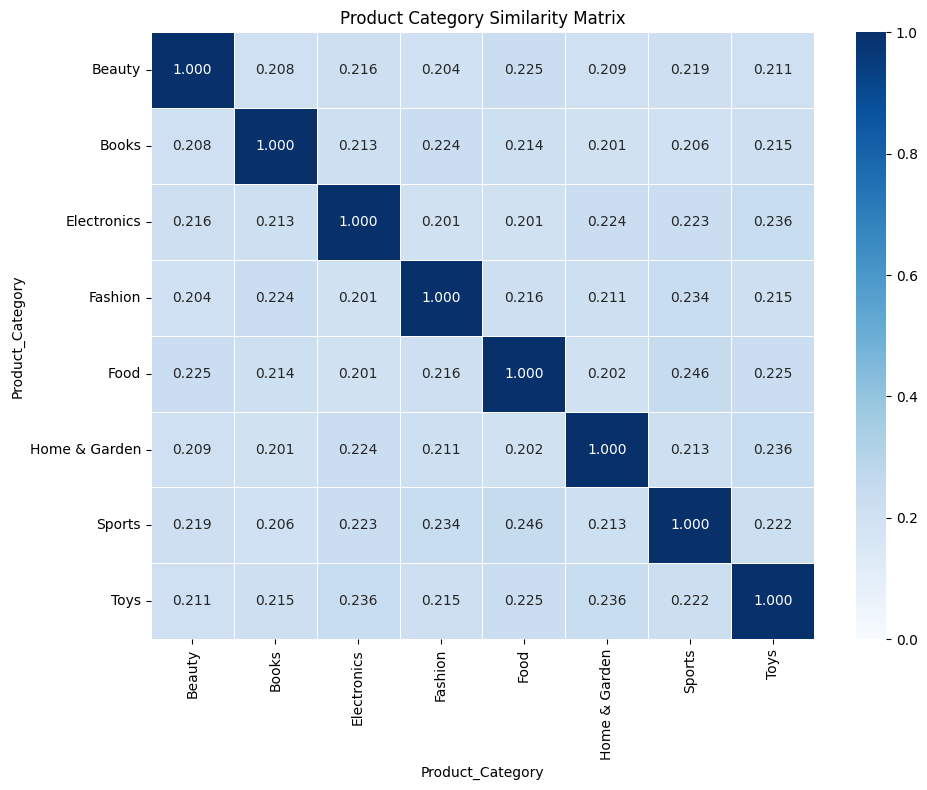

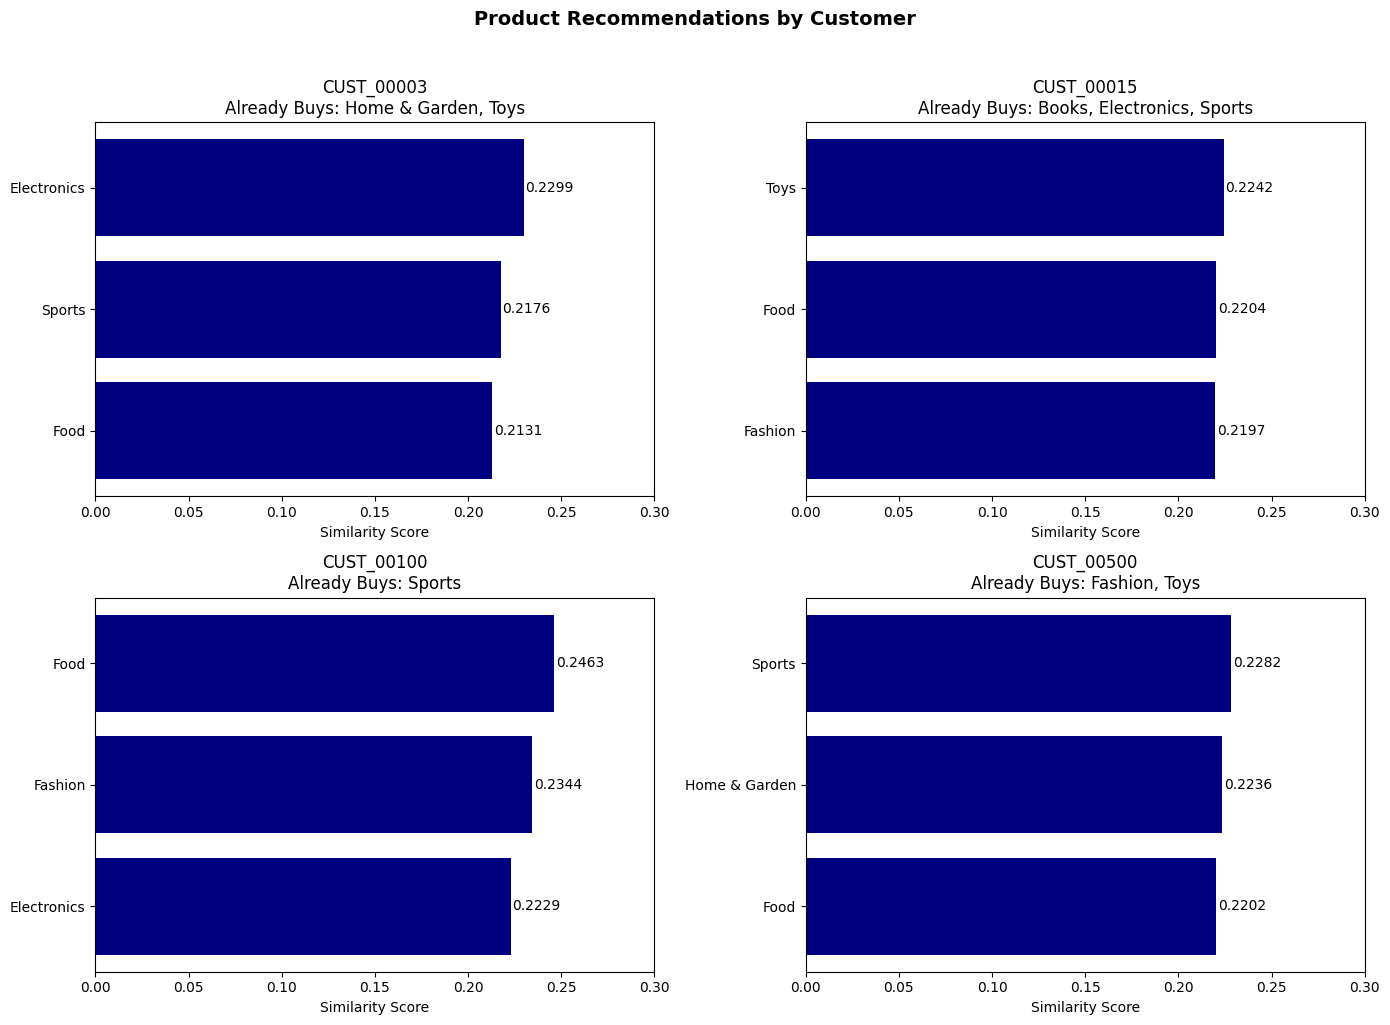

In [10]:
# Visualize Category Similarity Matrix as Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    category_similarity_df,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title('Product Category Similarity Matrix')
plt.tight_layout()
plt.show()

# Visualize recommendations for all 4 test customers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

test_customers = ['CUST_00003', 'CUST_00015', 'CUST_00100', 'CUST_00500']

for idx, customer in enumerate(test_customers):
    bought = customer_product_matrix.loc[customer]
    bought_categories = bought[bought > 0].index.tolist()
    
    scores = pd.Series(dtype=float)
    for category in bought_categories:
        similar = category_similarity_df[category]\
            .drop(bought_categories, errors='ignore')
        scores = pd.concat([scores, similar])
    
    recommendations = scores.groupby(scores.index).mean()\
        .sort_values(ascending=False)\
        .head(3)
    
    axes[idx].barh(
        recommendations.index[::-1],
        recommendations.values[::-1],
        color='navy'
    )
    axes[idx].set_title(f'{customer}\nAlready Buys: {", ".join(bought_categories)}')
    axes[idx].set_xlabel('Similarity Score')
    axes[idx].set_xlim(0, 0.30)
    
    for i, (val) in enumerate(recommendations.values[::-1]):
        axes[idx].text(val + 0.001, i, f'{val:.4f}', va='center')

plt.suptitle('Product Recommendations by Customer', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Generate recommendations for all customers
print("Generating recommendations for all customers...")

all_recommendations = []

for customer_id in customer_product_matrix.index:
    
    # Get categories already bought
    bought = customer_product_matrix.loc[customer_id]
    bought_categories = bought[bought > 0].index.tolist()
    
    # Skip customers with no purchases
    if len(bought_categories) == 0:
        continue
    
    # Get similarity scores
    scores = pd.Series(dtype=float)
    for category in bought_categories:
        similar = category_similarity_df[category]\
            .drop(bought_categories, errors='ignore')
        scores = pd.concat([scores, similar])
    
    # Get top 3 recommendations
    recommendations = scores.groupby(scores.index).mean()\
        .sort_values(ascending=False)\
        .head(3)
    
    # Store results
    all_recommendations.append({
        'Customer_ID'        : customer_id,
        'Already_Buys'       : ', '.join(bought_categories),
        'Recommendation_1'   : recommendations.index[0] if len(recommendations) > 0 else '',
        'Score_1'            : round(recommendations.iloc[0], 4) if len(recommendations) > 0 else 0,
        'Recommendation_2'   : recommendations.index[1] if len(recommendations) > 1 else '',
        'Score_2'            : round(recommendations.iloc[1], 4) if len(recommendations) > 1 else 0,
        'Recommendation_3'   : recommendations.index[2] if len(recommendations) > 2 else '',
        'Score_3'            : round(recommendations.iloc[2], 4) if len(recommendations) > 2 else 0,
    })

# Convert to DataFrame
recommendations_df = pd.DataFrame(all_recommendations)

print(f"✅ Recommendations generated for {len(recommendations_df)} customers!")
print("\nSample Output:")
print(recommendations_df.head(10))

Generating recommendations for all customers...
✅ Recommendations generated for 5000 customers!

Sample Output:
  Customer_ID                  Already_Buys Recommendation_1  Score_1  \
0  CUST_00001  Books, Home & Garden, Sports             Toys   0.2245   
1  CUST_00002                  Beauty, Food           Sports   0.2324   
2  CUST_00003           Home & Garden, Toys      Electronics   0.2299   
3  CUST_00004                       Fashion           Sports   0.2344   
4  CUST_00005  Fashion, Home & Garden, Toys           Sports   0.2232   
5  CUST_00006                  Beauty, Food           Sports   0.2324   
6  CUST_00007                       Fashion           Sports   0.2344   
7  CUST_00008                  Sports, Toys             Food   0.2355   
8  CUST_00009                       Fashion           Sports   0.2344   
9  CUST_00010        Beauty, Books, Fashion           Sports   0.2195   

  Recommendation_2  Score_2 Recommendation_3  Score_3  
0          Fashion   0.2230 

In [12]:
# Export to Excel
recommendations_df.to_excel(
    'customer_recommendations.xlsx',
    index=False,
    sheet_name='Recommendations'
)

# Export to CSV as backup
recommendations_df.to_csv(
    'customer_recommendations.csv',
    index=False
)

print("✅ Files saved successfully!")
print("\nFiles created:")
print("  1. customer_recommendations.xlsx")
print("  2. customer_recommendations.csv")
print(f"\nTotal customers: {len(recommendations_df)}")
print(f"Total columns:   {len(recommendations_df.columns)}")
print("\nColumn names:")
for col in recommendations_df.columns:
    print(f"  → {col}")

✅ Files saved successfully!

Files created:
  1. customer_recommendations.xlsx
  2. customer_recommendations.csv

Total customers: 5000
Total columns:   8

Column names:
  → Customer_ID
  → Already_Buys
  → Recommendation_1
  → Score_1
  → Recommendation_2
  → Score_2
  → Recommendation_3
  → Score_3
